<a href="https://colab.research.google.com/github/JaimeB252019/PARCIAL4-BELLOSO-PALACIOS-JAIME-DANEL2520192019/blob/main/Ejer03EV04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ocultar warnings
warnings.filterwarnings("ignore")

CARGA DE ARCHIVO

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/JaimeB252019/PARCIAL4-BELLOSO-PALACIOS-JAIME-DANEL2520192019/refs/heads/main/Archivos/clave_C_agrupacion.csv', delimiter=',')

print("Dataset cargado correctamente")

Dataset cargado correctamente


1. SELECCIONAR VARIABLES ADECUADAS PARA CLUSTERING.

In [4]:
# Seleccionar variables numéricas
variables = df.select_dtypes(include=np.number)

print(variables.head())

   edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0    30       809            7.62           92.58          8.85         1   
1    31      1024            7.44           83.28          8.93         0   
2    35       702            3.56           32.52          6.95         4   
3    35      1155            3.65          108.81          7.01        12   
4    37       644            3.77           52.21          4.40         7   

   antiguedad_meses  
0                19  
1                15  
2                 1  
3                27  
4                 6  


2. JUSTIFICAR POR QUÉ SELECCIONÓ ESAS VARIABLES.

Se seleccionaron variables numéricas porque K-Means trabaja mejor con datos cuantitativos y permite medir distancias entre registros.

3. NORMALIZAR O ESCALAR LOS DATOS CORRECTAMENTE.

In [7]:
from sklearn.preprocessing import StandardScaler

# Eliminar valores nulos
variables = variables.dropna()

# Escalar datos
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(variables)

print(datos_escalados)

[[-0.61518286 -0.43707133  0.72862841 ...  1.04108301 -0.70778896
   0.11043087]
 [-0.51600031  0.10121285  0.66999729 ...  1.08470785 -1.19542264
  -0.2039489 ]
 [-0.11927015 -0.70496159 -0.59382906 ...  0.00499293  0.75511206
  -1.30427812]
 ...
 [ 1.1701029  -0.11660447  0.12928808 ...  1.1283327  -0.70778896
   0.66059548]
 [-1.80537336 -0.24429048 -0.67200389 ... -0.09861608  0.26747839
  -1.30427812]
 [ 0.97173782 -0.2292686  -0.84789724 ... -1.29829933  1.24274574
  -0.59692362]]


4. APLICAR EL MÉTODO DEL CODO O UNA TÉCNICA PARA SELECCIONAR EL NÚMERO DE GRUPOS.

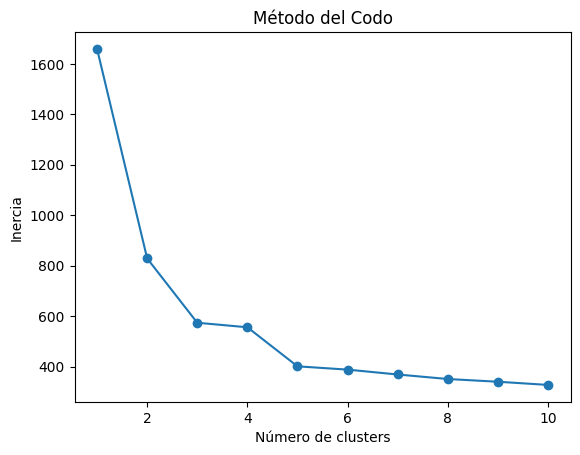

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1,11):

    modelo = KMeans(n_clusters=k, random_state=42)

    modelo.fit(datos_escalados)

    inercia.append(modelo.inertia_)

plt.plot(range(1,11), inercia, marker='o')

plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.show()

5. APLICAR K-MEANS U OTRO ALGORITMO DE AGRUPACIÓN.

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(datos_escalados)

print(clusters)

[2 2 1 1 1 1 0 0 1 0 0 2 0 1 1 1 0 1 1 1 1 1 2 0 2 1 0 1 2 0 2 2 1 2 0 0 0
 2 1 1 0 2 1 0 1 2 2 2 2 1 1 1 0 1 2 0 1 1 1 1 1 2 2 1 2 0 1 1 2 0 0 1 1 0
 1 1 1 1 1 2 1 2 2 2 0 1 0 0 0 0 0 1 2 0 1 2 0 1 0 1 1 1 0 0 2 1 2 1 1 2 1
 0 2 2 1 2 1 0 0 2 1 1 2 1 2 1 2 0 1 1 2 1 2 2 1 2 0 2 1 1 0 2 2 2 2 1 2 1
 1 1 1 1 1 1 1 2 1 1 0 0 2 2 1 2 0 1 0 1 2 0 2 1 1 2 2 1 1 1 0 0 0 1 1 1 0
 2 1 1 2 0 1 1 1 1 2 2 1 2 1 1 1 1 1 1 0 0 0 0 2 1 1 0 1 1 0 0 1 0 1 1 1 1
 0 1 1 1 1 0 2 1 1 2 2 2 2 1 1]


6. AGREGAR LA COLUMNA DEL GRUPO O CLUSTER AL DATASET ORIGINAL.

In [11]:
# Eliminar también esas filas del dataframe original
df = df.loc[variables.index]

# Agregar clusters
df["Cluster"] = clusters

print(df.head())

  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     C-R0098    30       809            7.62           92.58          8.85   
1     C-R0087    31      1024            7.44           83.28          8.93   
2     C-R0014    35       702            3.56           32.52          6.95   
3     C-R0123    35      1155            3.65          108.81          7.01   
4     C-R0198    37       644            3.77           52.21          4.40   

   reclamos  antiguedad_meses  Cluster  
0         1                19        2  
1         0                15        2  
2         4                 1        1  
3        12                27        1  
4         7                 6        1  


7. VISUALIZAR LOS GRUPOS MEDIANTE GRÁFICOS.

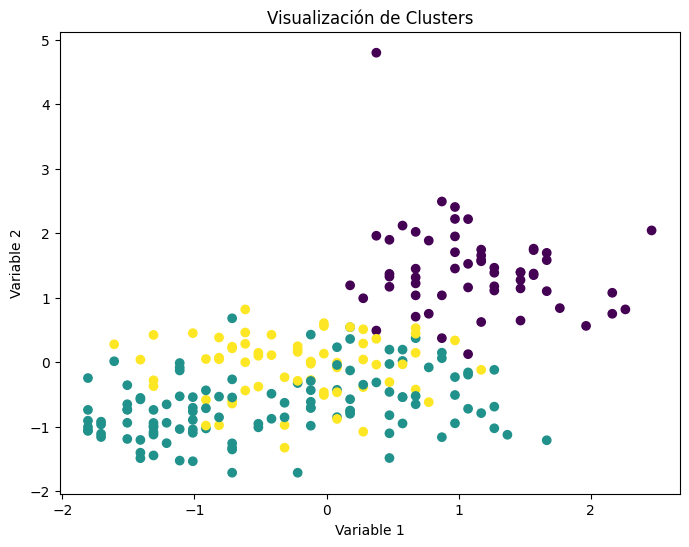

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    datos_escalados[:,0],
    datos_escalados[:,1],
    c=clusters
)

plt.title("Visualización de Clusters")

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")

plt.show()

8. INTERPRETAR CADA GRUPO ENCONTRADO.

Cluster 0: Grupo con características similares entre sí.

Cluster 1: Grupo con comportamiento diferente al cluster 0.

Cluster 2: Segmento con patrones específicos dentro del dataset.

9. PROPONER ACCIONES DE NEGOCIO PARA CADA GRUPO.

1. Crear estrategias específicas para cada grupo.

2. Personalizar promociones según el comportamiento de cada cluster.

3. Identificar clientes o registros con mayor valor para la empresa.

El análisis de agrupación con K-Means permitió identificar diferentes grupos dentro del dataset con características similares entre sí. Para realizar el proceso fue necesario seleccionar variables numéricas, limpiar valores nulos y normalizar los datos, logrando así un análisis más preciso y equilibrado entre las variables.

Mediante el método del codo se determinó una cantidad adecuada de clusters, permitiendo segmentar los datos en grupos con comportamientos distintos. Esto ayudó a detectar patrones y diferencias importantes entre los registros analizados.

Con base en los resultados obtenidos, el modelo de negocio podría tomar decisiones más estratégicas, como crear promociones específicas para cada segmento, personalizar servicios o productos según el comportamiento de cada grupo y enfocar recursos en los clientes o áreas con mayor potencial. Además, este análisis facilita comprender mejor el comportamiento de los datos y optimizar la toma de decisiones empresariales.